In [1]:
# Define a Reusable Evaluation Helper Function

def plot_evaluation(y_true, y_prob, model_name, threshold=0.5):
    """
    Plots confusion matrix and Precision-Recall curve side by side.
    Call this after training every model.
    """
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'])
    axes[0].set_title(f'{model_name} — Confusion Matrix')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # Precision-Recall curve
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    axes[1].plot(rec, prec, color='#4C72B0', lw=2, label=f'AP = {ap:.3f}')
    axes[1].axhline(y_true.mean(), color='gray', linestyle='--',
                    label=f'Random = {y_true.mean():.3f}')
    axes[1].set_xlabel('Recall — Fraction of Fraud Caught')
    axes[1].set_ylabel('Precision — Fraction of Alerts That Are Real')
    axes[1].set_title(f'{model_name} — Precision-Recall Curve')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'../reports/figures/eval_{model_name.replace(" ","_").lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    print(classification_report(y_true, y_pred, target_names=['Legit', 'Fraud']))
    print(f"ROC-AUC:            {roc_auc_score(y_true, y_prob):.4f}")
    print(f"Avg Precision (AP): {average_precision_score(y_true, y_prob):.4f}")

print("Evaluation helper defined.")

Evaluation helper defined.


In [19]:
# ── All imports for modelling notebook ────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# ── Load .env constants ───────────────────────────────
from dotenv import load_dotenv
load_dotenv('../.env')
RANDOM_STATE = int(os.getenv('RANDOM_STATE', 42))
TEST_SIZE     = float(os.getenv('TEST_SIZE', 0.2))
SMOTE_RATIO   = float(os.getenv('SMOTE_RATIO', 0.3))

# ── Sklearn models ────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

# ── Sklearn metrics — ALL of them ─────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
    recall_score,
    precision_score
)

# ── Imbalanced learning ───────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Load processed data ───────────────────────────────
X_train_sc = pd.read_csv('../data/processed/X_train_sc.csv')
X_test_sc  = pd.read_csv('../data/processed/X_test_sc.csv')
y_train    = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test     = pd.read_csv('../data/processed/y_test.csv').squeeze()

# ── Saved objects from notebook 01 ───────────────────
scaler = joblib.load('../models/scaler.pkl')

print(f"RANDOM_STATE: {RANDOM_STATE}")
print(f"X_train_sc:   {X_train_sc.shape}")
print(f"X_test_sc:    {X_test_sc.shape}")
print("All imports loaded successfully.")

RANDOM_STATE: 42
X_train_sc:   (227845, 36)
X_test_sc:    (56962, 36)
All imports loaded successfully.


=== Logistic Regression Baseline ===


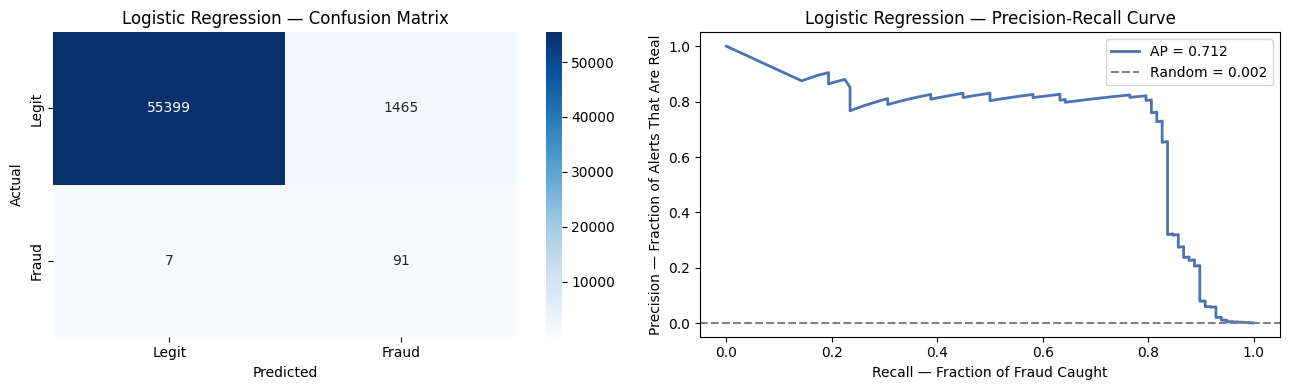

              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.06      0.93      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC:            0.9724
Avg Precision (AP): 0.7120


In [3]:
# Train a Logistic Regression Baseline Model

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight='balanced',  # Auto-adjusts weights to compensate for imbalance
    max_iter=1000,
    random_state=RANDOM_STATE,
    C=0.01                    # Conservative regularization — start small
)

lr.fit(X_train_sc, y_train)

y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]
y_pred_lr = lr.predict(X_test_sc)

print("=== Logistic Regression Baseline ===")
plot_evaluation(y_test, y_prob_lr, 'Logistic Regression')

=== Random Forest ===


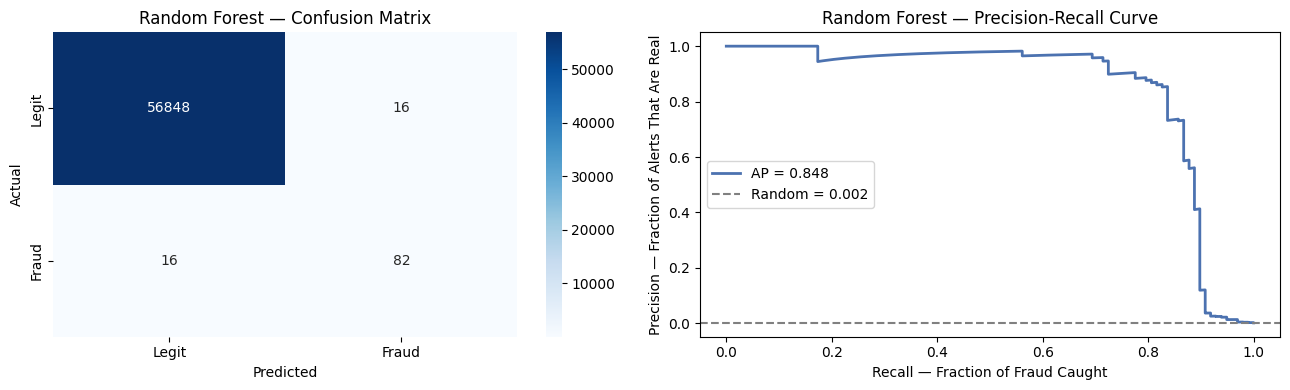

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.84      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC:            0.9807
Avg Precision (AP): 0.8482


In [4]:
# Train Train Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,         # 200 trees — stable without being too slow
    max_depth=12,             # Limit depth to prevent overfitting on majority class
    min_samples_leaf=4,       # Each leaf needs at least 4 samples before splitting stops
    class_weight='balanced',  # Adjusts sample weights proportional to class frequency
    n_jobs=-1,                # Use all CPU cores
    random_state=RANDOM_STATE
)

rf.fit(X_train_sc, y_train)

y_prob_rf = rf.predict_proba(X_test_sc)[:, 1]
y_pred_rf = rf.predict(X_test_sc)

print("=== Random Forest ===")
plot_evaluation(y_test, y_prob_rf, 'Random Forest')

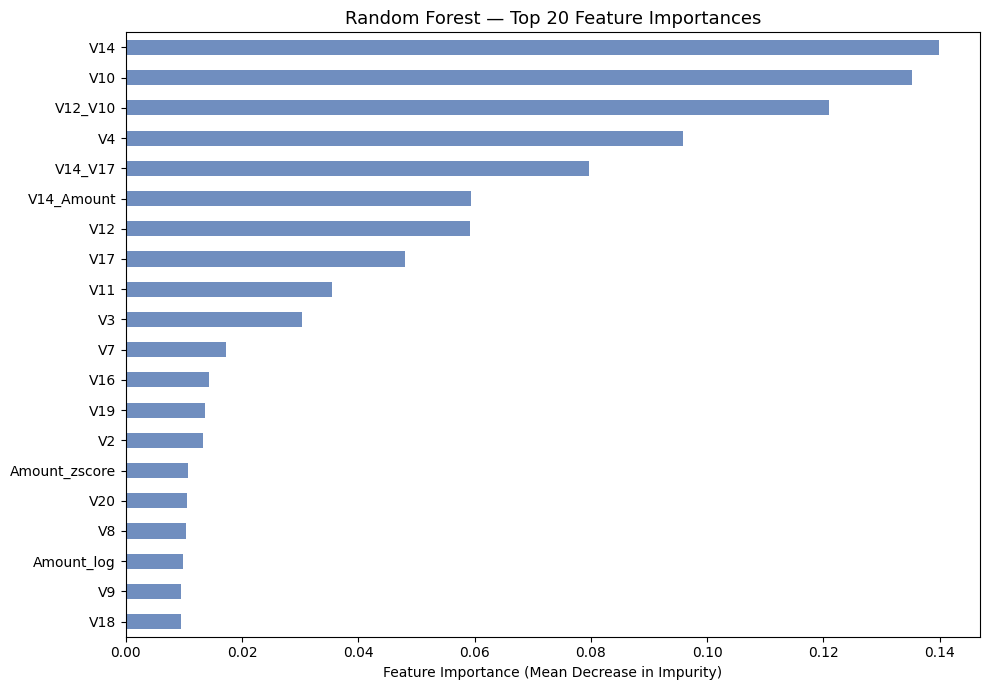

Top 10 features:
 V14           0.139946
V10           0.135180
V12_V10       0.120942
V4            0.095904
V14_V17       0.079696
V14_Amount    0.059445
V12           0.059222
V17           0.048072
V11           0.035501
V3            0.030238
dtype: float64


In [5]:
# Feature importance from Random Forest

importances = pd.Series(
    rf.feature_importances_,
    index=X_train_sc.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
importances.head(20).plot.barh(color='#4C72B0', alpha=0.8)
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance (Mean Decrease in Impurity)')
plt.title('Random Forest — Top 20 Feature Importances', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 features:\n", importances.head(10))

In [6]:
#Threshold Tuning (Critical for Imbalanced Problems)

#The default classification threshold is 0.5 — but this is arbitrary.
#For fraud detection, we might accept more false alarms (lower Precision)
#to catch more actual fraud (higher Recall). The optimal balance
#depends on the business cost of each type of error

thresholds = np.arange(0.1, 0.9, 0.02)
f1_scores  = []

for t in thresholds:
    preds = (y_prob_rf >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds, pos_label=1, zero_division=0))

best_t = thresholds[np.argmax(f1_scores)]
print(f"Best threshold: {best_t:.2f}  |  Best Fraud F1: {max(f1_scores):.4f}")

# Compare default vs optimal threshold
y_pred_opt = (y_prob_rf >= best_t).astype(int)
print(f"\n--- Default threshold: 0.50 ---")
print(classification_report(y_test, y_pred_rf, target_names=['Legit','Fraud']))
print(f"--- Optimal threshold: {best_t:.2f} ---")
print(classification_report(y_test, y_pred_opt, target_names=['Legit','Fraud']))

Best threshold: 0.56  |  Best Fraud F1: 0.8438

--- Default threshold: 0.50 ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.84      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

--- Optimal threshold: 0.56 ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.86      0.83      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [7]:
# SMOTE + Advanced Classifiers

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy=0.3,  # Make fraud = 30% of majority class (not 50% — too artificial)
    k_neighbors=5,          # Interpolate between 5 nearest fraud neighbours per point
    random_state=RANDOM_STATE
)

X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print(f"Before SMOTE — Fraud: {y_train.sum():,}  |  Legit: {(y_train==0).sum():,}")
print(f"After  SMOTE — Fraud: {y_train_sm.sum():,}  |  Legit: {(y_train_sm==0).sum():,}")
print(f"\nNew training fraud rate: {y_train_sm.mean():.2%}")

Before SMOTE — Fraud: 394  |  Legit: 227,451
After  SMOTE — Fraud: 68,235  |  Legit: 227,451

New training fraud rate: 23.08%


[0]	validation_0-aucpr:0.56387
[50]	validation_0-aucpr:0.71774
[100]	validation_0-aucpr:0.82585
[150]	validation_0-aucpr:0.84688
[200]	validation_0-aucpr:0.85542
[250]	validation_0-aucpr:0.85954
[299]	validation_0-aucpr:0.86547
=== XGBoost + SMOTE ===


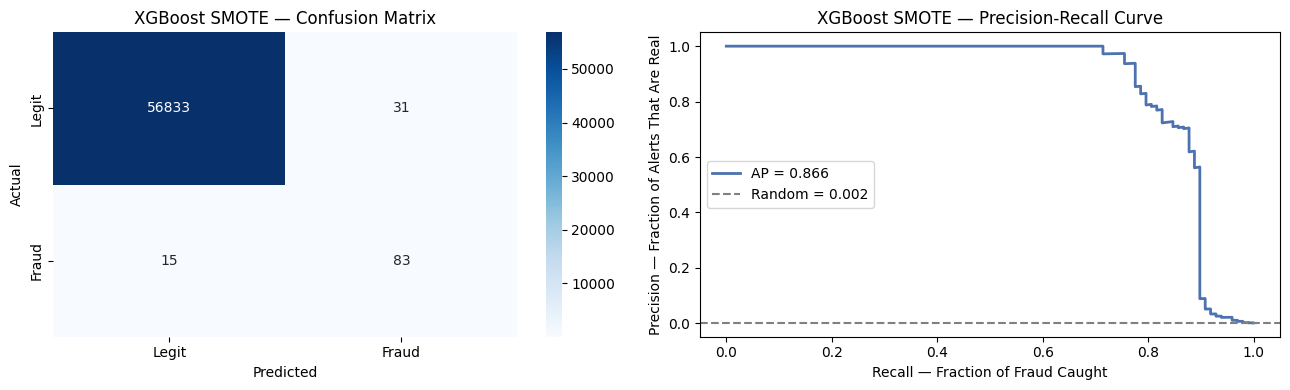

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.73      0.85      0.78        98

    accuracy                           1.00     56962
   macro avg       0.86      0.92      0.89     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC:            0.9774
Avg Precision (AP): 0.8656


In [8]:
# XGboost

import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,        # Use 80% of rows per tree — reduces overfitting
    colsample_bytree=0.8, # Use 80% of features per tree
    eval_metric='aucpr',  # Optimize directly for Precision-Recall AUC
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test_sc, y_test)],
    verbose=50
)

y_prob_xgb = xgb_model.predict_proba(X_test_sc)[:, 1]
y_pred_xgb = xgb_model.predict(X_test_sc)

print("=== XGBoost + SMOTE ===")
plot_evaluation(y_test, y_prob_xgb, 'XGBoost SMOTE')

=== LightGBM + SMOTE ===


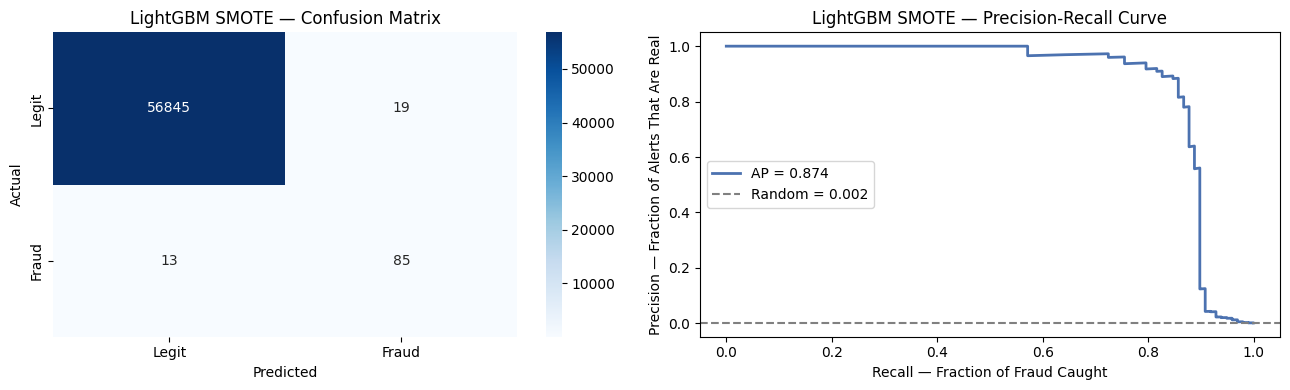

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.82      0.87      0.84        98

    accuracy                           1.00     56962
   macro avg       0.91      0.93      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC:            0.9771
Avg Precision (AP): 0.8744


In [9]:
# Light GBM

import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    num_leaves=63,        # More leaves = more complex model — watch for overfitting
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(X_train_sm, y_train_sm)

y_prob_lgb = lgb_model.predict_proba(X_test_sc)[:, 1]
y_pred_lgb = lgb_model.predict(X_test_sc)

print("=== LightGBM + SMOTE ===")
plot_evaluation(y_test, y_prob_lgb, 'LightGBM SMOTE')

In [10]:
# Model Comparison Summary

models = {
    'Logistic Regression': y_prob_lr,
    'Random Forest':       y_prob_rf,
    'XGBoost + SMOTE':     y_prob_xgb,
    'LightGBM + SMOTE':    y_prob_lgb,
}

rows = []
for name, probs in models.items():
    preds = (probs >= 0.5).astype(int)
    rows.append({
        'Model':             name,
        'ROC-AUC':           round(roc_auc_score(y_test, probs), 4),
        'Avg Precision':     round(average_precision_score(y_test, probs), 4),
        'Recall (fraud)':    round(recall_score(y_test, preds), 4),
        'Precision (fraud)': round(precision_score(y_test, preds, zero_division=0), 4),
        'F1 (fraud)':        round(f1_score(y_test, preds, zero_division=0), 4),
    })

summary = pd.DataFrame(rows).set_index('Model')
print(summary.to_string())
summary.to_csv('../reports/model_comparison.csv')
print("\nSaved to reports/model_comparison.csv")

                     ROC-AUC  Avg Precision  Recall (fraud)  Precision (fraud)  F1 (fraud)
Model                                                                                     
Logistic Regression   0.9724         0.7120          0.9286             0.0585      0.1100
Random Forest         0.9807         0.8482          0.8367             0.8367      0.8367
XGBoost + SMOTE       0.9774         0.8656          0.8469             0.7281      0.7830
LightGBM + SMOTE      0.9771         0.8744          0.8673             0.8173      0.8416

Saved to reports/model_comparison.csv


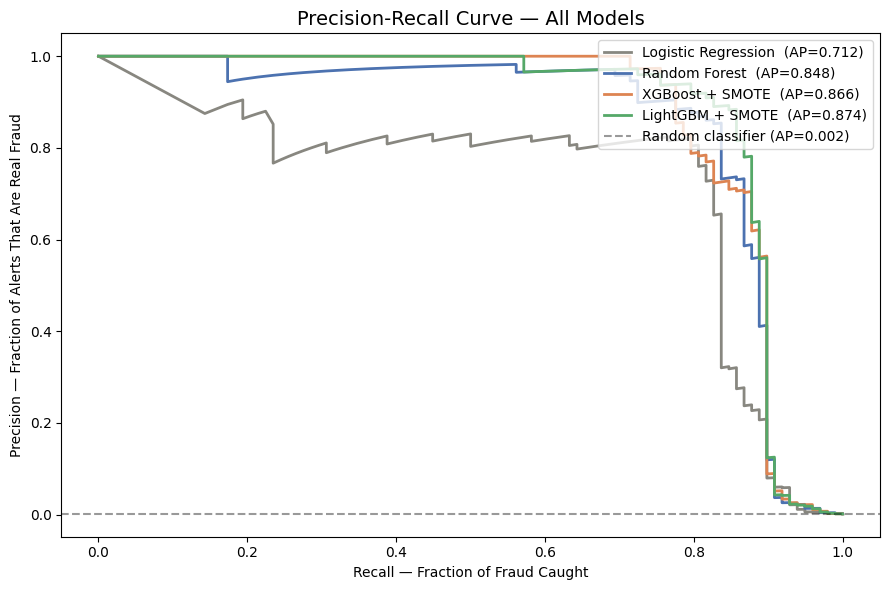

Saved to reports/figures/pr_curve_comparison.png


In [11]:
# Overlaid PR curves for all models

colors = ['#888780', '#4C72B0', '#DD8452', '#55A868']
fig, ax = plt.subplots(figsize=(9, 6))

for (name, probs), color in zip(models.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax.plot(rec, prec, label=f'{name}  (AP={ap:.3f})', color=color, lw=2)

ax.axhline(y_test.mean(), color='black', linestyle='--', alpha=0.4,
           label=f'Random classifier (AP={y_test.mean():.3f})')
ax.set_xlabel('Recall — Fraction of Fraud Caught')
ax.set_ylabel('Precision — Fraction of Alerts That Are Real Fraud')
ax.set_title('Precision-Recall Curve — All Models', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/figures/pr_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to reports/figures/pr_curve_comparison.png")

In [12]:
# 5-Fold Cross-Validation on Best Model

from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
best_model = lgb_model  # Update to whichever model won

cv_results = cross_validate(
    best_model, X_train_sc, y_train,
    cv=cv,
    scoring=['roc_auc', 'average_precision'],
    return_train_score=True,
    n_jobs=-1
)

print("5-Fold Stratified CV — Best Model:")
print(f"  ROC-AUC  — mean: {cv_results['test_roc_auc'].mean():.4f} "
      f"± {cv_results['test_roc_auc'].std():.4f}")
print(f"  Avg Prec — mean: {cv_results['test_average_precision'].mean():.4f} "
      f"± {cv_results['test_average_precision'].std():.4f}")

5-Fold Stratified CV — Best Model:
  ROC-AUC  — mean: 0.9787 ± 0.0120
  Avg Prec — mean: 0.8512 ± 0.0237


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 500, 'num_leaves': 63}
Best CV Avg Precision: 1.0000

Test Avg Precision (tuned): 0.8773
Test ROC-AUC (tuned):       0.9801


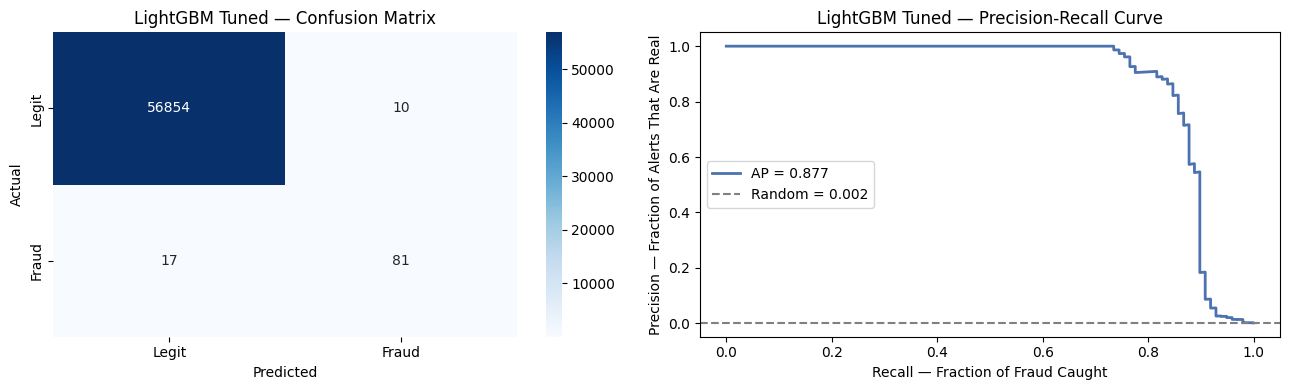

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.89      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC:            0.9801
Avg Precision (AP): 0.8773
Tuned model saved.


In [13]:
# Hyperparameter Tuning with GridSearchCV

from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
# Each combination will be tested with 5-fold CV
param_grid = {
    'n_estimators':  [300, 500],
    'max_depth':     [6, 8, 10],
    'learning_rate': [0.03, 0.05, 0.1],
    'num_leaves':    [31, 63]
}

lgb_tuned = lgb.LGBMClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

grid = GridSearchCV(
    lgb_tuned,
    param_grid,
    cv=5,
    scoring='average_precision',   # optimise for your primary metric
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_sm, y_train_sm)

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV Avg Precision: {grid.best_score_:.4f}")

# Evaluate the tuned model on test set
y_prob_lgb_tuned = grid.best_estimator_.predict_proba(X_test_sc)[:, 1]
print(f"\nTest Avg Precision (tuned): {average_precision_score(y_test, y_prob_lgb_tuned):.4f}")
print(f"Test ROC-AUC (tuned):       {roc_auc_score(y_test, y_prob_lgb_tuned):.4f}")

plot_evaluation(y_test, y_prob_lgb_tuned, 'LightGBM Tuned')

# Save the best model
joblib.dump(grid.best_estimator_, '../models/lgb_tuned.pkl')
print("Tuned model saved.")

In [14]:
# SMOTE ratio experiment

print("Testing SMOTE sampling ratios...\n")
ratio_results = []

for ratio in [0.1, 0.2, 0.3, 0.4, 0.5]:
    # Apply SMOTE at this ratio
    sm_exp = SMOTE(sampling_strategy=ratio, random_state=RANDOM_STATE)
    X_sm_exp, y_sm_exp = sm_exp.fit_resample(X_train_sc, y_train)

    # Train a quick LightGBM
    lgb_exp = lgb.LGBMClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        verbose=-1,
        n_jobs=-1
    )
    lgb_exp.fit(X_sm_exp, y_sm_exp)

    prob = lgb_exp.predict_proba(X_test_sc)[:, 1]
    pred = lgb_exp.predict(X_test_sc)

    ratio_results.append({
        'SMOTE Ratio': ratio,
        'Avg Precision': round(average_precision_score(y_test, prob), 4),
        'Recall':        round(recall_score(y_test, pred), 4),
        'Precision':     round(precision_score(y_test, pred, zero_division=0), 4),
        'F1':            round(f1_score(y_test, pred, zero_division=0), 4),
        'Train Fraud %': f"{y_sm_exp.mean():.1%}"
    })
    print(f"Ratio {ratio} → AP: {average_precision_score(y_test, prob):.4f} | "
          f"Recall: {recall_score(y_test, pred):.4f}")

ratio_df = pd.DataFrame(ratio_results)
print("\nFull results:")
print(ratio_df.to_string(index=False))

# Use the best ratio going forward
best_ratio = ratio_df.loc[ratio_df['Avg Precision'].idxmax(), 'SMOTE Ratio']
print(f"\nBest SMOTE ratio: {best_ratio}")

Testing SMOTE sampling ratios...

Ratio 0.1 → AP: 0.8702 | Recall: 0.8469
Ratio 0.2 → AP: 0.8241 | Recall: 0.8367
Ratio 0.3 → AP: 0.8389 | Recall: 0.8061
Ratio 0.4 → AP: 0.7615 | Recall: 0.8061
Ratio 0.5 → AP: 0.8132 | Recall: 0.8265

Full results:
 SMOTE Ratio  Avg Precision  Recall  Precision     F1 Train Fraud %
         0.1         0.8702  0.8469     0.8737 0.8601          9.1%
         0.2         0.8241  0.8367     0.8817 0.8586         16.7%
         0.3         0.8389  0.8061     0.8681 0.8360         23.1%
         0.4         0.7615  0.8061     0.8778 0.8404         28.6%
         0.5         0.8132  0.8265     0.9000 0.8617         33.3%

Best SMOTE ratio: 0.1



=== Threshold Analysis — LightGBM + SMOTE ===
 Threshold  Recall  Precision    F1  Fraud Caught (TP)  False Alarms (FP)  Missed Fraud (FN)  Total Alerts
       0.2   0.878      0.642 0.741                 86                 48                 12           134
       0.3   0.878      0.723 0.793                 86                 33                 12           119
       0.4   0.878      0.782 0.827                 86                 24                 12           110
       0.5   0.867      0.817 0.842                 85                 19                 13           104
       0.6   0.857      0.848 0.853                 84                 15                 14            99
       0.7   0.847      0.883 0.865                 83                 11                 15            94


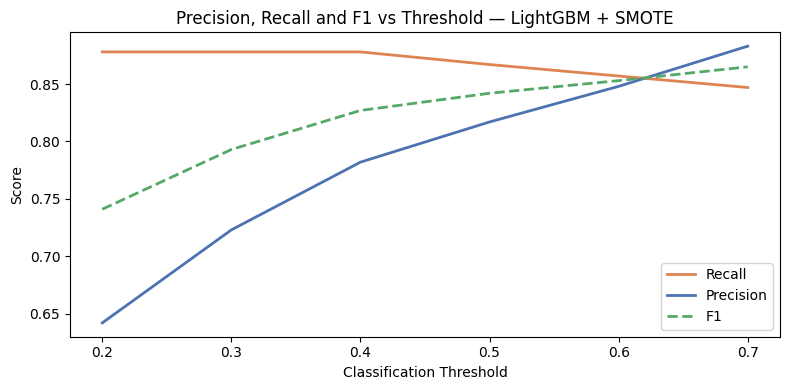

In [15]:
# Threshold Decision Tool

def threshold_report(y_true, y_prob, model_name):
    """
    Shows Recall, Precision, F1, and alert volume at multiple thresholds.
    Helps choose the right operating point based on business cost trade-offs.
    """
    thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
    rows = []

    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        tp = ((preds == 1) & (y_true == 1)).sum()
        fp = ((preds == 1) & (y_true == 0)).sum()
        fn = ((preds == 0) & (y_true == 1)).sum()

        rows.append({
            'Threshold':        t,
            'Recall':           round(recall_score(y_true, preds), 3),
            'Precision':        round(precision_score(y_true, preds, zero_division=0), 3),
            'F1':               round(f1_score(y_true, preds, zero_division=0), 3),
            'Fraud Caught (TP)': tp,
            'False Alarms (FP)': fp,
            'Missed Fraud (FN)': fn,
            'Total Alerts':     int(preds.sum())
        })

    report = pd.DataFrame(rows)
    print(f"\n=== Threshold Analysis — {model_name} ===")
    print(report.to_string(index=False))

    # Plot Precision and Recall vs threshold
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(report['Threshold'], report['Recall'],    label='Recall',    color='#DD8452', lw=2)
    ax.plot(report['Threshold'], report['Precision'], label='Precision', color='#4C72B0', lw=2)
    ax.plot(report['Threshold'], report['F1'],        label='F1',        color='#55A868', lw=2, linestyle='--')
    ax.set_xlabel('Classification Threshold')
    ax.set_ylabel('Score')
    ax.set_title(f'Precision, Recall and F1 vs Threshold — {model_name}')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'../reports/figures/threshold_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    return report

threshold_df = threshold_report(y_test, y_prob_lgb, 'LightGBM + SMOTE')

In [16]:
# Isolation Forest (Anomaly Detection Comparison)

from sklearn.ensemble import IsolationForest

# contamination = expected proportion of anomalies in the data
# Set to the actual fraud rate in the dataset
fraud_rate = y_train.mean()
print(f"Setting contamination to actual fraud rate: {fraud_rate:.4%}")

iso = IsolationForest(
    n_estimators=200,
    contamination=fraud_rate,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

iso.fit(X_train_sc)

# Isolation Forest returns -1 for anomaly (fraud), 1 for normal (legit)
iso_pred   = iso.predict(X_test_sc)
iso_binary = (iso_pred == -1).astype(int)

# Also get anomaly scores for PR curve
iso_scores = -iso.score_samples(X_test_sc)  # negate so higher = more anomalous

print("\n=== Isolation Forest (Unsupervised Baseline) ===")
print(classification_report(y_test, iso_binary, target_names=['Legit', 'Fraud']))
print(f"Avg Precision: {average_precision_score(y_test, iso_scores):.4f}")
print(f"ROC-AUC:       {roc_auc_score(y_test, iso_scores):.4f}")

# Add to your comparison table
print("\nKey insight: Isolation Forest uses NO labels during training.")
print("Any supervised model should significantly outperform it.")
print("If it does not, your supervised pipeline has a problem.")

Setting contamination to actual fraud rate: 0.1729%

=== Isolation Forest (Unsupervised Baseline) ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.33      0.37      0.35        98

    accuracy                           1.00     56962
   macro avg       0.66      0.68      0.67     56962
weighted avg       1.00      1.00      1.00     56962

Avg Precision: 0.2456
ROC-AUC:       0.9592

Key insight: Isolation Forest uses NO labels during training.
Any supervised model should significantly outperform it.
If it does not, your supervised pipeline has a problem.


In [20]:
    # Save and load final model for deployment

import joblib
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.pkl')
print("Scaler saved.")

    # ── Save the best model ───────────────────────────────
joblib.dump(lgb_model,  '../models/lgb_final.pkl')
joblib.dump(scaler,     '../models/scaler.pkl')

print("Model and scaler saved to models/")

# ── Prediction function ───────────────────────────────
def predict_fraud(input_dict, threshold=0.5):
    """
    Takes a dictionary of feature values and returns a fraud prediction.

    Parameters:
        input_dict : dict — feature names and values for one transaction
        threshold  : float — classification threshold (default 0.5)

    Returns:
        dict with prediction, probability, and risk level

    Example:
        predict_fraud({
            'V1': -1.36, 'V2': -0.07, ...,
            'Amount_log': 4.5, 'Hour': 23, 'Is_night': 1,
            'V14_V17': 2.3, 'V12_V10': -1.1, 'V14_Amount': -3.2,
            'Amount_is_round': 0, 'Amount_zscore': 1.2
        })
    """
    model  = joblib.load('../models/lgb_final.pkl')
    scl    = joblib.load('../models/scaler.pkl')

    input_df = pd.DataFrame([input_dict])

    # Apply scaling to the same columns used during training
    cols_to_scale = ['Amount_log', 'Amount_zscore', 'Hour']
    input_df[cols_to_scale] = scl.transform(input_df[cols_to_scale])

    prob  = model.predict_proba(input_df)[0, 1]
    label = int(prob >= threshold)

    if prob >= 0.7:
        risk = 'HIGH'
    elif prob >= 0.4:
        risk = 'MEDIUM'
    else:
        risk = 'LOW'

    return {
        'prediction':  'FRAUD' if label == 1 else 'LEGIT',
        'probability': round(prob, 4),
        'risk_level':  risk,
        'threshold':   threshold
    }

# Test it
example = {c: 0.0 for c in X_train_sc.columns}  # all-zero example
result  = predict_fraud(example)
print("\nExample prediction:")
for k, v in result.items():
    print(f"  {k}: {v}")

Scaler saved.
Model and scaler saved to models/

Example prediction:
  prediction: LEGIT
  probability: 0.051
  risk_level: LOW
  threshold: 0.5


In [ ]:
models = {
    'Logistic Regression': y_prob_lr,
    'Random Forest':       y_prob_rf,
    'XGBoost + SMOTE':     y_prob_xgb,
    'LightGBM + SMOTE':    y_prob_lgb,
}

rows = []
for name, probs in models.items():
    preds = (probs >= 0.5).astype(int)
    rows.append({
        'Model':             name,
        'ROC-AUC':           round(roc_auc_score(y_test, probs), 4),
        'Avg Precision':     round(average_precision_score(y_test, probs), 4),
        'Recall':            round(recall_score(y_test, preds), 4),
        'Precision':         round(precision_score(y_test, preds, zero_division=0), 4),
        'F1':                round(f1_score(y_test, preds, zero_division=0), 4),
    })

summary = pd.DataFrame(rows).set_index('Model')

# Print clean for copy-pasting into README
print(summary.to_string())

# Save as CSV to reports folder
summary.to_csv('../reports/model_comparison.csv')
print("\nSaved to reports/model_comparison.csv")

                     ROC-AUC  Avg Precision  Recall  Precision      F1
Model                                                                 
Logistic Regression   0.9724         0.7120  0.9286     0.0585  0.1100
Random Forest         0.9807         0.8482  0.8367     0.8367  0.8367
XGBoost + SMOTE       0.9774         0.8656  0.8469     0.7281  0.7830
LightGBM + SMOTE      0.9771         0.8744  0.8673     0.8173  0.8416

Saved to reports/model_comparison.csv


: 